## Lecture 2

In this notebook we implement a **Conditional GAN (CGAN)** on the MNIST dataset. Unlike the vanilla GAN from the previous notebook, here both the Generator and the Discriminator are conditioned on the class label (digit 0-9), so that after training we can request the Generator to produce a specific digit.

In [1]:
import os

import torch
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
# Device selection adapted to run locally on macOS with Apple GPU (MPS) support,
# falling back to CUDA (if available) and finally CPU.
device = torch.device('cpu')
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')

device

device(type='mps')

In [3]:
noise_dim = 100
label_dim = 10

Generator Model

The Generator's input is the concatenation of the noise vector (`noise_dim`) and the one-hot encoded class label (`label_dim`), so that the network learns to generate a specific digit conditioned on the label.

In [4]:
class Generator(torch.nn.Module):

    def __init__(self):

        super(Generator, self).__init__()

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=noise_dim + label_dim,
                out_features=240,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            # Fully Connected Layer 2
            torch.nn.Linear(
                in_features=240,
                out_features=240,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            # Fully Connected Layer 3
            torch.nn.Linear(
                in_features=240,
                out_features=240,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            # Fully Connected Layer 4
            torch.nn.Linear(
                in_features=240,
                out_features=240,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            # Fully Connected Layer 5
            torch.nn.Linear(
                in_features=240,
                out_features=240,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            # Fully Connected Layer 6
            torch.nn.Linear(
                in_features=240,
                out_features=784,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, noise, labels):
        inputs = torch.cat([noise, labels], dim=1)
        return self.fcn(inputs)

Discriminator Model

The Discriminator's input is the concatenation of the flattened image (784 pixels) and the one-hot encoded class label, so it learns to judge whether an image is real/fake **for a given label**.

In [5]:
class Discriminator(torch.nn.Module):

    def __init__(self):

        super(Discriminator, self).__init__()

        self.fcn = torch.nn.Sequential(
            # Fully Connected Layer 1
            torch.nn.Linear(
                in_features=784 + label_dim,
                out_features=240,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            # Fully Connected Layer 2
            torch.nn.Linear(
                in_features=240,
                out_features=240,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            # Fully Connected Layer 3
            torch.nn.Linear(
                in_features=240,
                out_features=240,
                bias=True
            ),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.5),
            # Fully Connected Layer 4
            torch.nn.Linear(
                in_features=240,
                out_features=1,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, images, labels):
        flattened = images.view(images.size(0), -1)
        inputs = torch.cat([flattened, labels], dim=1)
        return self.fcn(inputs)

MNIST Dataset

We reuse the local dataset loading pattern from Notebook 4 (`./data/mnist`), instead of the Colab-specific mounted paths used in the original lecture notebook.

In [6]:
import torchvision


class FlattenTransform:

    def __call__(self, inputs):
        return inputs.view(inputs.shape[0], -1)


data_train = torchvision.datasets.MNIST(
    './data/mnist',
    train=True,
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        FlattenTransform()
    ])
)

100.0%
100.0%
100.0%
100.0%


In [7]:
BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(
    data_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

Onehot Encoding

The class labels need to be one-hot encoded (`label_dim` = 10) before being concatenated to the noise vector (Generator) or to the flattened image (Discriminator).

In [8]:
def encodeOneHot(labels):
    ret = torch.FloatTensor(labels.shape[0], label_dim)
    ret.zero_()
    ret.scatter_(dim=1, index=labels.view(-1, 1), value=1)
    return ret

Optimizer

In [9]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

discriminator_optimizer = torch.optim.SGD(
    discriminator.parameters(),
    lr=0.003,
    momentum=0.5
)

generator_optimizer = torch.optim.SGD(
    generator.parameters(),
    lr=0.001,
    momentum=0.5
)

criterion = torch.nn.BCELoss()

Visualize Function

In [10]:
def visualizeGAN(tgt_pth, images, labels, epoch):

    categories = [str(i) for i in range(10)]

    fig, axes = plt.subplots(2, 5, figsize=(20, 18))

    fig.suptitle('Epoch {}'.format(str(epoch).zfill(4)))

    for row, axe in enumerate(axes):
        for col, cell in enumerate(axe):
            cell.imshow(
                images[row * 5 + col],
                cmap='gray'
            )

            cell.set_title('{}'.format(
                categories[torch.argmax(labels[row * 5 + col])]
            ))

            cell.axis("off")

    plt.axis("off")
    plt.tight_layout()

    fig.savefig(os.path.join(tgt_pth, '{}.jpg'.format(str(epoch).zfill(4))))

    plt.close()

Train GANs

In [11]:
real_labels = torch.ones(BATCH_SIZE, 1).to(device)
fake_labels = torch.zeros(BATCH_SIZE, 1).to(device)

test_z = (2 * torch.randn(10, noise_dim) - 1).to(device)
test_y = encodeOneHot(torch.tensor(np.arange(0, 10))).to(device)

num_epochs = 512
num_steps = len(train_loader) // BATCH_SIZE

In [12]:
visuals_dir = 'visuals-cgan-mnist'

if not os.path.exists(visuals_dir):
    os.mkdir(visuals_dir)

In [13]:
d_loss_ls = []
g_loss_ls = []

for epoch in range(num_epochs):

    d_loss = 0
    g_loss = 0

    for i, (images, labels) in enumerate(train_loader):

        if i == num_steps:
            break

        # Train Discriminator
        real_images = images.to(device)
        real_conditions = encodeOneHot(labels).to(device)

        fake_conditions = encodeOneHot(torch.randint(0, 10, (BATCH_SIZE,))).to(device)
        fake_images = generator(
            (2 * torch.randn(BATCH_SIZE, noise_dim) - 1).to(device),
            fake_conditions
        )

        discriminator_optimizer.zero_grad()

        real_outputs = discriminator(real_images, real_conditions)
        fake_outputs = discriminator(fake_images, fake_conditions)

        d_x = criterion(real_outputs, real_labels)
        d_g_z = criterion(fake_outputs, fake_labels)

        d_x.backward()
        d_g_z.backward()

        discriminator_optimizer.step()

        # Train Generator
        z = (2 * torch.randn(BATCH_SIZE, noise_dim) - 1).to(device)
        y = encodeOneHot(torch.randint(0, 10, (BATCH_SIZE,))).to(device)

        generator.zero_grad()

        outputs = discriminator(generator(z, y), y)

        loss = criterion(outputs, real_labels)

        loss.backward()

        generator_optimizer.step()

        # Loss Log
        d_loss = d_x.item() + d_g_z.item()
        g_loss += loss.item()

    if epoch % 10 == 0:
        print('e:{}, G:{:.3f}, D:{:.3f}'.format(epoch, g_loss / num_steps, d_loss))

    # Loss Log for Plot
    d_loss_ls.append(d_loss)
    g_loss_ls.append(g_loss / num_steps)

    # Visualize Results
    if epoch % 10 == 0:
        generated = generator(test_z, test_y).detach().cpu().view(-1, 28, 28)
        visualizeGAN(visuals_dir, generated, test_y, epoch)

e:0, G:0.653, D:1.378
e:10, G:1.208, D:1.028
e:20, G:3.362, D:0.527
e:30, G:5.184, D:0.216
e:40, G:6.776, D:0.089
e:50, G:8.118, D:0.033
e:60, G:8.949, D:0.034
e:70, G:9.313, D:0.017
e:80, G:3.998, D:0.523
e:90, G:1.909, D:0.534
e:100, G:1.588, D:0.735
e:110, G:1.165, D:0.814
e:120, G:1.225, D:0.842
e:130, G:1.901, D:0.519
e:140, G:2.442, D:0.336
e:150, G:2.740, D:0.363
e:160, G:3.101, D:0.250
e:170, G:3.066, D:0.480
e:180, G:3.024, D:0.274
e:190, G:3.111, D:0.440
e:200, G:2.841, D:0.311
e:210, G:2.991, D:0.281
e:220, G:2.906, D:0.261
e:230, G:2.921, D:0.421
e:240, G:2.918, D:0.360
e:250, G:2.646, D:0.496
e:260, G:2.878, D:0.404
e:270, G:2.848, D:0.408
e:280, G:3.019, D:0.559
e:290, G:2.908, D:0.430
e:300, G:2.990, D:0.439
e:310, G:2.933, D:0.431
e:320, G:2.903, D:0.500
e:330, G:2.836, D:0.408
e:340, G:2.829, D:0.335
e:350, G:3.004, D:0.504
e:360, G:2.892, D:0.385
e:370, G:2.814, D:0.610
e:380, G:2.794, D:0.520
e:390, G:2.678, D:0.350
e:400, G:2.983, D:0.306
e:410, G:3.157, D:0.345
e:4

Visualize Outputs

Here we visualize one generated image per digit (0-9) using the trained Generator's output.

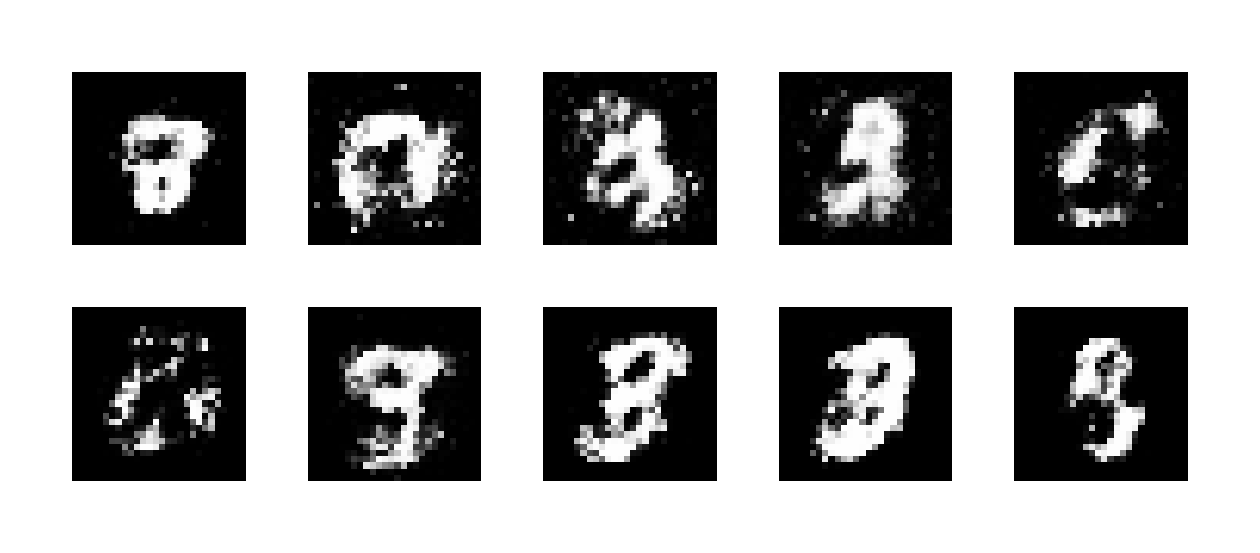

In [14]:
# Visualize Results
test_z = (2 * torch.randn(10, noise_dim) - 1).to(device)

generated = generator(test_z, test_y).detach().cpu().view(-1, 1, 28, 28)

grid = torchvision.utils.make_grid(
    generated,
    nrow=5,
    padding=10,
    pad_value=1
)

img = np.transpose(
    grid.numpy(),
    (1, 2, 0)
)

fig = plt.figure(figsize=(16, 16))
plt.axis("off")
plt.imshow(img);

Visualize Loss

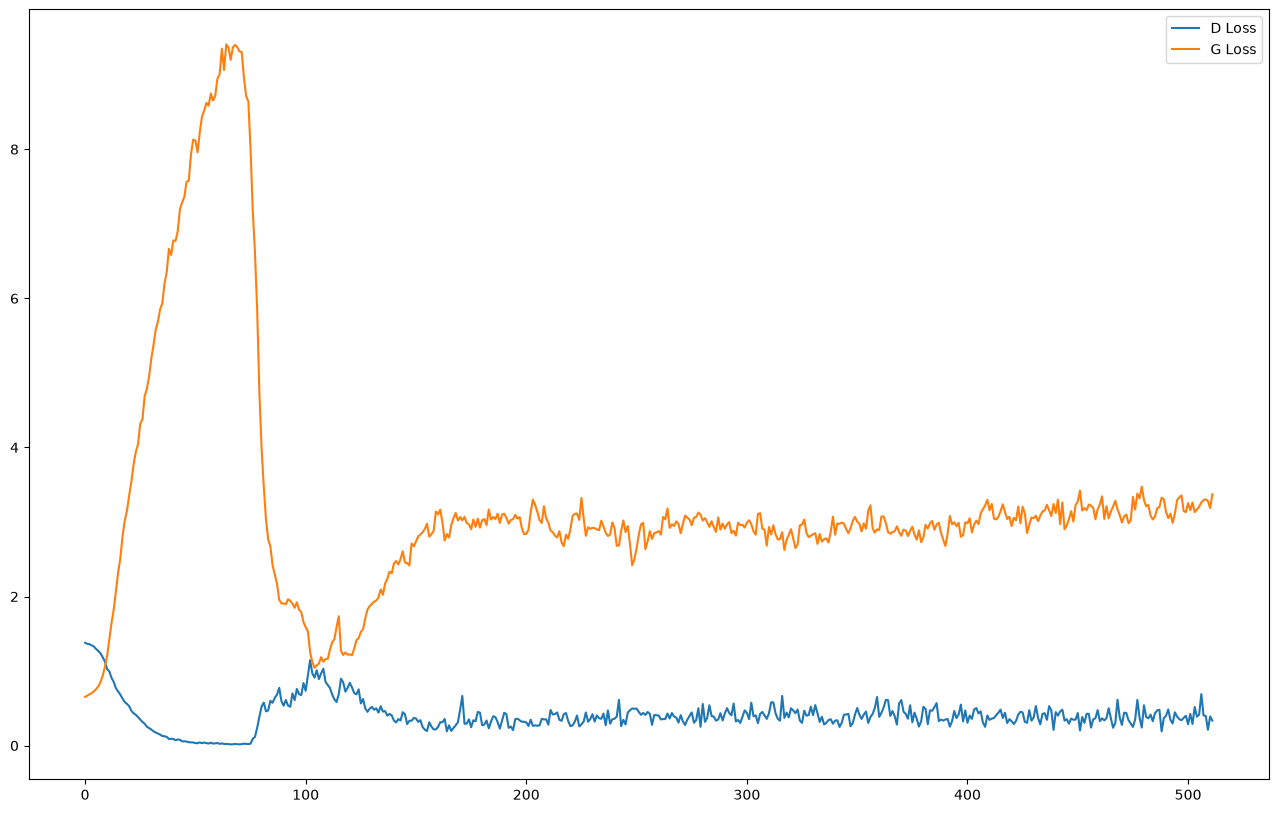

In [15]:
fig = plt.figure(figsize=(16, 10))
plt.plot(d_loss_ls, label='D Loss')
plt.plot(g_loss_ls, label='G Loss')
plt.legend()
plt.show();

Google Collaboratory

Notebook: [https://colab.research.google.com/drive/1O0ld95mJUZLsxu3AJy8xCNMm5phbeYh7](https://colab.research.google.com/drive/1O0ld95mJUZLsxu3AJy8xCNMm5phbeYh7)

## Bonus: Learning Rate Decay

### Basic Formula

$$\alpha_t = \dfrac{1}{1 + \alpha_0 \times 0.001}$$

This is a bonus section (not required to complete the assignment) exploring `torch.optim.lr_scheduler` learning-rate decay. We first design a tiny model (two-neuron XOR classifier) to find a good decay factor, and then apply the same idea (a `LambdaLR` schedule) to the Conditional GAN training above.

### Model Design

In [16]:
class MLP(torch.nn.Module):

    def __init__(self):

        super(MLP, self).__init__()

        self.network = torch.nn.Sequential(
            torch.nn.Linear(
                in_features=2,
                out_features=1,
                bias=True
            ),
            torch.nn.Sigmoid()
        )

    def forward(self, inputs):
        return self.network(inputs)

XOR Dataset

In [17]:
X = torch.tensor(
    [
        [0, 0],
        [0, 1],
        [1, 0],
        [1, 1]
    ],
    dtype=torch.float
)

y = torch.tensor(
    [
        [0],
        [1],
        [1],
        [0]
    ],
    dtype=torch.float
)

Optimizer

In [18]:
model = MLP()

opt = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.7
)

Scheduler

In [19]:
def decayLR(e):
    return 1 / (1 + e * 0.001)


sched = torch.optim.lr_scheduler.LambdaLR(
    opt,
    decayLR
)

Objective Function

In [20]:
criterion = torch.nn.BCELoss()

Training

In [21]:
lr_logs = []

for epoch in range(10000):

    model.zero_grad()

    y_ = model(X)

    loss = criterion(y_, y)

    loss.backward()

    opt.step()

    sched.step()

    lr_logs.append(sched.get_last_lr())

Visualize LR

We use an array to log the learning rate value using the scheduler to get the learning rate, so finally we visualize the decaying rate as the number of steps increases: the blue curve drops sharply at the beginning and then decays slowly as training progresses, similar to how a model's loss converges.

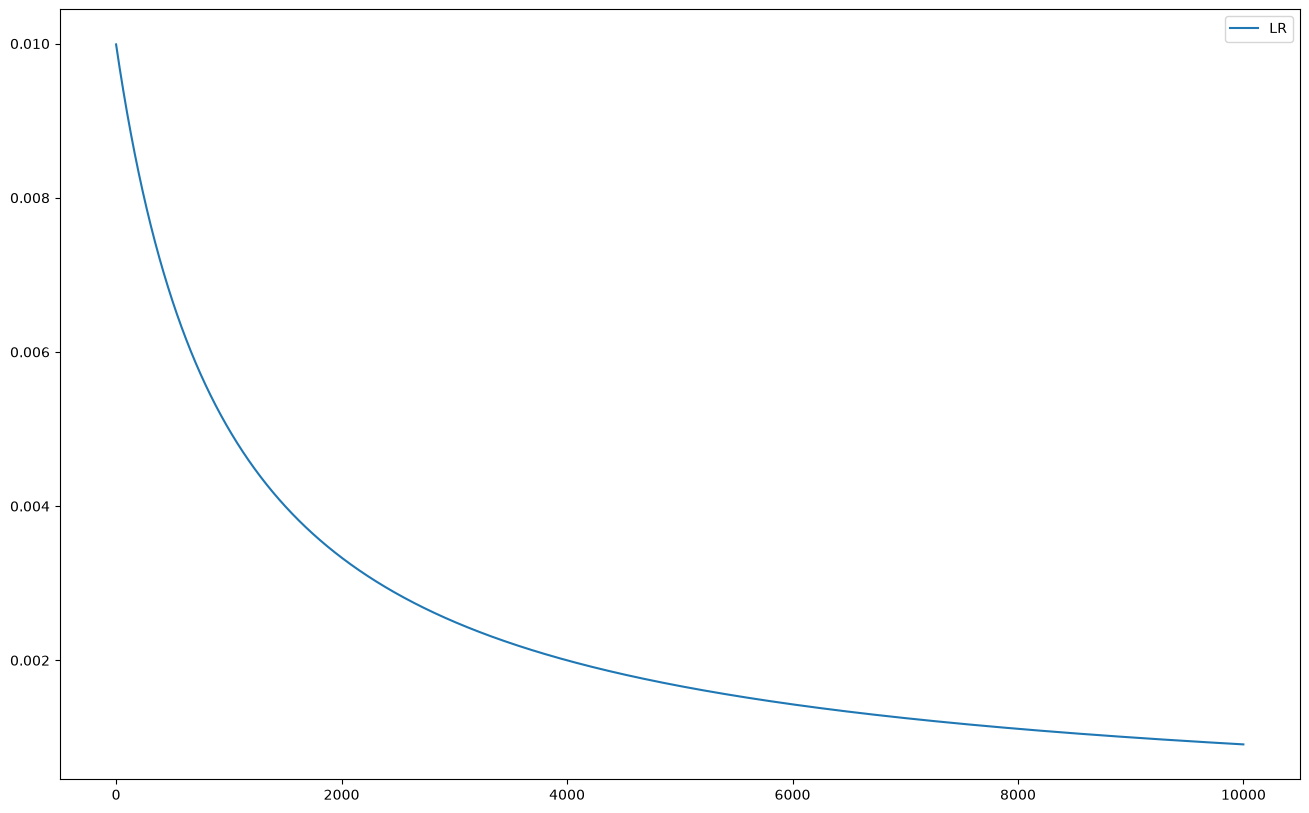

In [22]:
fig = plt.figure(figsize=(16, 10))
plt.plot(lr_logs, label='LR')
plt.legend()
plt.show();

### Applying Learning Rate Decay to the GAN

Now that we've validated the `LambdaLR` scheduler on a toy XOR model, let's apply the same idea to a Conditional GAN. To keep this bonus experiment self-contained (and to show the technique on a second dataset, as in the lecture), we train a fresh Generator/Discriminator pair on **FashionMNIST**, using the same local-dataset pattern as the rest of this notebook (`./data/fashionMNIST`) instead of a Colab-mounted path.

MNIST Dataset

In [23]:
data_train = torchvision.datasets.FashionMNIST(
    './data/fashionMNIST',
    train=True,
    download=True,
    transform=torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        FlattenTransform()
    ])
)

100.0%
100.0%
100.0%
100.0%


In [24]:
BATCH_SIZE = 64

train_loader = torch.utils.data.DataLoader(
    data_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

Optimizer

In [25]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

discriminator_optimizer = torch.optim.SGD(
    discriminator.parameters(),
    lr=0.003,
    momentum=0.5
)

generator_optimizer = torch.optim.SGD(
    generator.parameters(),
    lr=0.001,
    momentum=0.5
)

criterion = torch.nn.BCELoss()

Lambda Learning Rate

We apply a piecewise decay function to both the discriminator and generator optimizers using `LambdaLR`: the learning rate stays constant for the first 200 epochs, then decays with progressively smaller factors so that training keeps making useful progress and doesn't collapse to trivial outputs.

In [26]:
def decayLR(e):
    if e < 200:
        return 1
    elif e < 400:
        return 1 / (1 + e * 0.1)
    elif e < 600:
        return 1 / (1 + e * 0.001)
    elif e < 800:
        return 1 / (1 + e * 0.00001)
    elif e < 1000:
        return 1 / (1 + e * 0.0000001)
    else:
        return 1 / (1 + e * 0.000000001)


discriminator_scheduler = torch.optim.lr_scheduler.LambdaLR(
    discriminator_optimizer,
    decayLR
)

generator_scheduler = torch.optim.lr_scheduler.LambdaLR(
    generator_optimizer,
    decayLR
)

Visualize Function

Here we visualize the outputs we have obtained during training using the `visualizeGAN` utility for visualization, redefined below with FashionMNIST's category names.

In [27]:
def visualizeGAN(tgt_pth, images, labels, epoch):

    categories = [
        'T-shirt/top',
        'Trouser',
        'Pullover',
        'Dress',
        'Coat',
        'Sandal',
        'Shirt',
        'Sneaker',
        'Bag',
        'Ankle boot'
    ]

    fig, axes = plt.subplots(2, 5, figsize=(20, 18))

    fig.suptitle('Epoch {}'.format(str(epoch).zfill(4)))

    for row, axe in enumerate(axes):
        for col, cell in enumerate(axe):
            cell.imshow(
                images[row * 5 + col],
                cmap='gray'
            )

            cell.set_title('{}'.format(
                categories[torch.argmax(labels[row * 5 + col])]
            ))

            cell.axis("off")

    plt.axis("off")
    plt.tight_layout()

    fig.savefig(os.path.join(tgt_pth, '{}.jpg'.format(str(epoch).zfill(4))))

    plt.close()

Onehot Encoding

We reuse `encodeOneHot` (`label_dim = 10`) defined earlier for the CGAN section — FashionMNIST also has 10 classes.

Train GANs

In [28]:
real_labels = torch.ones(BATCH_SIZE, 1).to(device)
fake_labels = torch.zeros(BATCH_SIZE, 1).to(device)

test_z = (2 * torch.randn(10, noise_dim) - 1).to(device)
test_y = encodeOneHot(torch.tensor(np.arange(0, 10))).to(device)

num_epochs = 2048
num_steps = len(train_loader) // BATCH_SIZE

In [29]:
visuals_dir = 'visuals-bonus-lr-decay-fashion-mnist'

if not os.path.exists(visuals_dir):
    os.mkdir(visuals_dir)

In [30]:
d_loss_ls = []
g_loss_ls = []
d_lr_ls = []
g_lr_ls = []

for epoch in range(num_epochs):

    # Loss Log
    d_counter = 0
    g_counter = 0
    d_loss = 0
    g_loss = 0

    for i, (images, labels) in enumerate(train_loader):

        if i == num_steps:
            break

        # Train Discriminator
        for _ in range(4):

            real_images = images.to(device)
            real_conditions = encodeOneHot(labels).to(device)

            fake_conditions = encodeOneHot(torch.randint(0, 10, (BATCH_SIZE,))).to(device)

            fake_images = generator(
                (2 * torch.randn(BATCH_SIZE, noise_dim) - 1).to(device),
                fake_conditions
            )

            discriminator_optimizer.zero_grad()

            real_outputs = discriminator(real_images, real_conditions)
            fake_outputs = discriminator(fake_images, fake_conditions)

            d_x = criterion(real_outputs, real_labels)
            d_g_z = criterion(fake_outputs, fake_labels)

            d_x.backward()
            d_g_z.backward()

            discriminator_optimizer.step()

            # Loss Log
            d_counter += 1
            d_loss = d_x.item() + d_g_z.item()

        # Train Generator
        z = (2 * torch.randn(BATCH_SIZE, noise_dim) - 1).to(device)
        y = encodeOneHot(torch.randint(0, 10, (BATCH_SIZE,))).to(device)

        generator.zero_grad()

        outputs = discriminator(generator(z, y), y)

        loss = criterion(outputs, real_labels)

        loss.backward()

        generator_optimizer.step()

        # LR Decay
        discriminator_scheduler.step()
        generator_scheduler.step()

        # Loss Log
        g_counter += 1
        g_loss += loss.item()

    # Loss Log
    if epoch % 10 == 0:
        print(
            'e:{}, G:{:.3f}, D:{:.3f}, G_LR:{}, D_LR:{}'.format(
                epoch,
                g_loss / g_counter,
                d_loss / d_counter,
                generator_scheduler.get_last_lr(),
                discriminator_scheduler.get_last_lr()
            )
        )

    # Loss Log for Plot
    g_loss_ls.append(g_loss / g_counter)
    d_loss_ls.append(d_loss / d_counter)

    # Learning Rate Decay Log
    g_lr_ls.append(generator_scheduler.get_last_lr())
    d_lr_ls.append(discriminator_scheduler.get_last_lr())

    # Visualize Results
    if epoch % 5 == 0:
        generated = generator(test_z, test_y).detach().cpu().view(-1, 28, 28)
        visualizeGAN(visuals_dir, generated, test_y, epoch)

e:0, G:0.725, D:0.025, G_LR:[0.001], D_LR:[0.003]
e:10, G:5.861, D:0.001, G_LR:[0.001], D_LR:[0.003]
e:20, G:6.934, D:0.001, G_LR:[3.289473684210526e-05], D_LR:[9.868421052631579e-05]
e:30, G:7.098, D:0.001, G_LR:[0.0006973500697350071], D_LR:[0.002092050209205021]
e:40, G:8.000, D:0.000, G_LR:[0.0006353240152477764], D_LR:[0.0019059720457433292]
e:50, G:8.893, D:0.000, G_LR:[0.000992910618186151], D_LR:[0.002978731854558453]
e:60, G:6.874, D:0.002, G_LR:[0.0009999146072925374], D_LR:[0.002999743821877612]
e:70, G:2.667, D:0.003, G_LR:[0.0009999006098793779], D_LR:[0.002999701829638134]
e:80, G:2.845, D:0.003, G_LR:[0.000999998866001286], D_LR:[0.0029999965980038582]
e:90, G:4.021, D:0.001, G_LR:[0.0009999987260016232], D_LR:[0.0029999961780048695]
e:100, G:4.801, D:0.001, G_LR:[0.0009999985860019995], D_LR:[0.0029999957580059983]
e:110, G:4.831, D:0.002, G_LR:[0.000999998446002415], D_LR:[0.0029999953380072447]
e:120, G:4.770, D:0.002, G_LR:[0.0009999983060028695], D_LR:[0.00299999491

In [31]:
# Visualize Results
generated = generator(test_z, test_y).detach().cpu().view(-1, 28, 28)

visualizeGAN(visuals_dir, generated, test_y, epoch)

Visualize Loss

So we can see again the same pattern as the original vanilla GAN training in Notebook 4: the Generator loss spikes early on and then oscillates as it competes with the Discriminator.

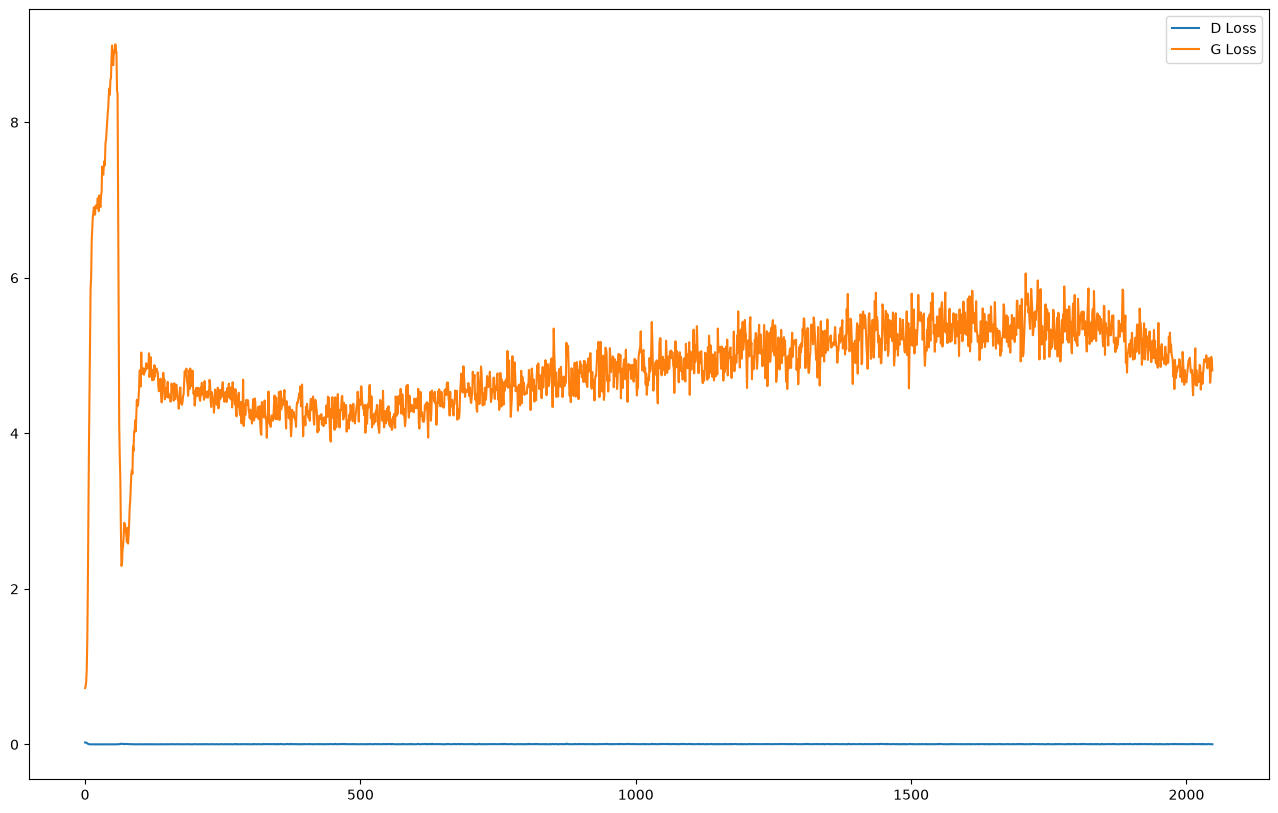

In [32]:
fig = plt.figure(figsize=(16, 10))
plt.plot(d_loss_ls, label='D Loss')
plt.plot(g_loss_ls, label='G Loss')
plt.legend()
plt.show();

Visualize Learning Rate Decay

Running this cell gives a visualization of the decaying rate for both the Discriminator and the Generator, over the course of training.

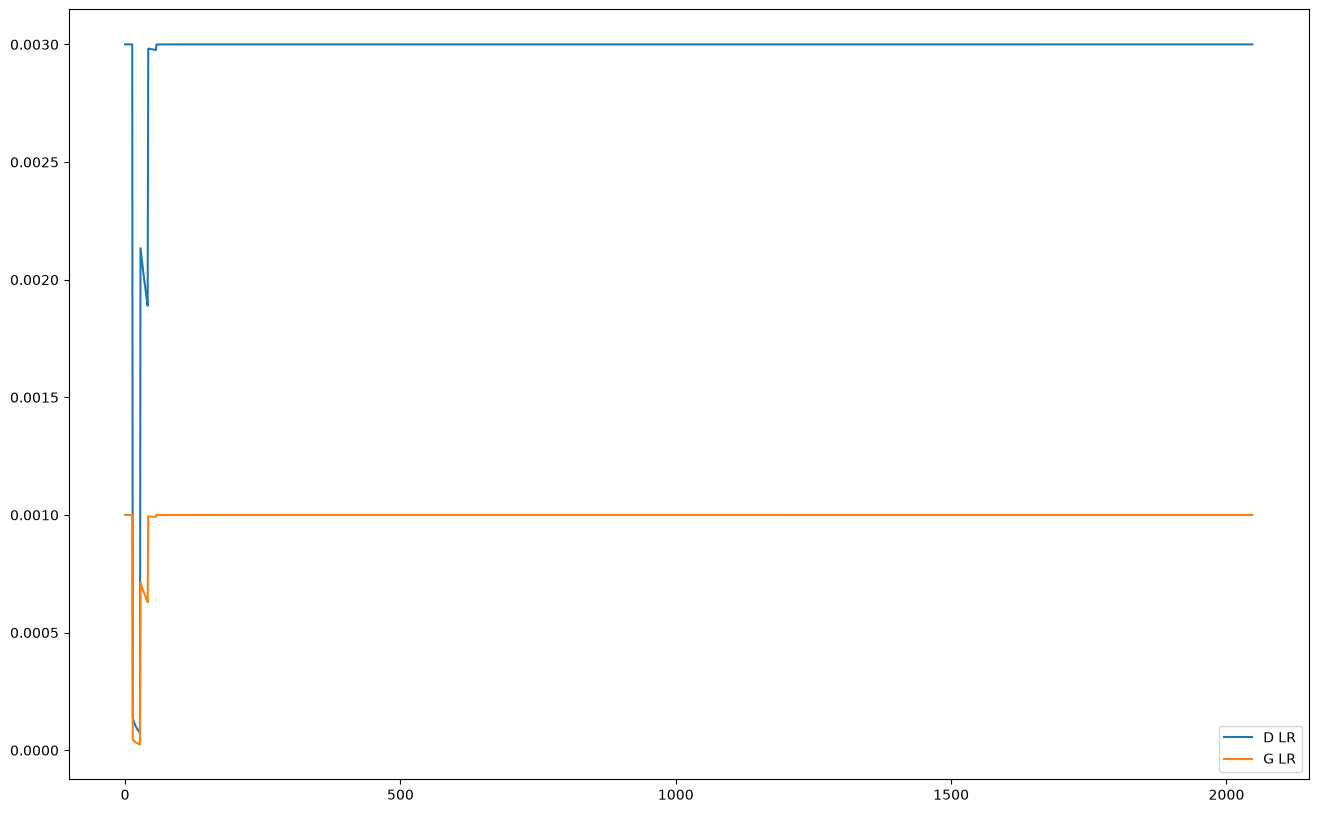

In [33]:
fig = plt.figure(figsize=(16, 10))
plt.plot(d_lr_ls, label='D LR')
plt.plot(g_lr_ls, label='G LR')
plt.legend()
plt.show();

Google Collaboratory

Notebook: [https://colab.research.google.com/drive/1O0ld95mJUZLsxu3AJy8xCNMm5phbeYh7](https://colab.research.google.com/drive/1O0ld95mJUZLsxu3AJy8xCNMm5phbeYh7)